# Решение домашнего задания #21

[задача](../../tasks/hometask_21.ipynb)

# Что будем делать:

Для данной задачи возьмем довольно базовую цель: будем определять, является ли текст ненавистническим или же нет (к слову, двольно много системы проваливают эту задачу, поэтому тема актуальна). А если точнее, будем пытаться на лету понять, начала ли модель генерировать ненавистнический текст (на самом деле, такая задача ничем не отлечима от простой подачи дружелюбного/ненавистнического текста в модель, поэтому это мы и будем делать). Основная мысль тут в том, что если модель начала генерировать ненавистнический текст, то она продолжит это делать, а значит, будет какое-то изменение внутренних представлений модели, которые мы и будем пытаться отследить.

PS: на самом деле, всё что будет показано далее легко обобщается на любую другую задачу поиска аномалий в тексте, и, в случае успеха, мы можем при генерации ответа просто смотреть на нужные слои и отрубать генерацию, когда заметим в них что-то подозрительное. Такой подход сразу поможет нам решить кучу проблем с безопасностью LLM, за счёт малого числа дополнительных вычислений.

# Модель и данные:

Для тестов возьмем одну из стандартных моделей в индустрии - `Llama 3.2 3B` (сейчас уже есть `llama 4`, но там размеры моделей от _17B_, что немного великовато) и будем проверять ее на датасете [Hate Speech and Offensive Language Dataset](https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset), который содержит ~25 тыс. текстов с разметкой на ненавистнические высказывания.

In [39]:
import os
import sys
import pickle
from collections import defaultdict

from tqdm.auto import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM

import kagglehub

In [ ]:
DATASET_NAME = "mrmorj/hate-speech-and-offensive-language-dataset"
MODEL_NAME = "meta-llama/Llama-3.2-3B"

In [ ]:
path = kagglehub.dataset_download(DATASET_NAME)
data = pd.read_csv(path + "/labeled_data.csv")

data = data[['tweet', 'class']]
data.head()

```
                                               tweet  class
0  !!! RT @mayasolovely: As a woman you shouldn't...      2
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...      1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...      1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...      1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...      1
```

In [ ]:
# float16 will be enough to see the differences in internal representations

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto")

tokenizer.pad_token = tokenizer.eos_token

model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

```
LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (rotary_emb): LlamaRotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_features=128256, bias=False)
)
```

In [ ]:
layer_representation_change = defaultdict(float)
layer_entropy = defaultdict(float)
layer_means = defaultdict(dict)
layer_squared_means = defaultdict(dict)

dl = DataLoader(list(zip(data['tweet'].tolist(), data['class'].tolist())), batch_size=128, shuffle=False, num_workers=32)


Для Оценки информативности слоев будем использовать несколько метрик:
1. косинусное сходство между входным представлением и представлением на слое
2. энтропия распределения представлений (чем выше - тем разнообразнее представления, что может говорить о лучшей разделимости классов)
3. LDR (Layer Discrimination Ratio) - отношение межклассового расстояния к внутриклассовому (чем выше - тем лучше разделимость классов)

PS: KL-дивергенция не будет ввиду сложности расчета для высокоразмерных данных.

In [ ]:
def get_data_cosine_similarity(data1, data2):
    cosine = torch.nn.functional.cosine_similarity(data1, data2)
    return cosine.mean().item()  # mean by time, mean by features, mean by batch

def get_data_entropy(data):
    probs = torch.nn.functional.softmax(data, dim=-1)
    log_probs = torch.nn.functional.log_softmax(data, dim=-1)
    entropy = -torch.sum(probs * log_probs, dim=1).mean() # sum by time, mean by features, mean by batch
    return entropy.item()

In [ ]:
batch_cnt = len(dl)
labels_cnt = {k: len(data[data['class'] == k]) for k in data['class'].unique()}

In [ ]:
for text, label in tqdm(dl):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
    input_ids = inputs["input_ids"]
    
    # Hook to get layer inputs and outputs
    def get_hook(layer_name):
        def hook(module, input, output):
            layer_representation_change[layer_name] += get_data_cosine_similarity(input[0], output) / batch_cnt
            layer_entropy[layer_name] += get_data_entropy(output) / batch_cnt

            time_meaned = output.detach().mean(dim=1)  # mean by time

            unique_labels = set(label.tolist())
            for lbl in unique_labels:
                indexes = [i for i, l in enumerate(label) if l == lbl]
                target = time_meaned[indexes].sum(dim=0)  # mean by batch
                
                target_squared_mean = target * target / labels_cnt[lbl]
                target = target / labels_cnt[lbl]

                if lbl not in layer_means[layer_name]:
                    layer_means[layer_name][lbl] = target
                    layer_squared_means[layer_name][lbl] = target_squared_mean
                else:
                    previous_mean = layer_means[layer_name][lbl]
                    previous_squared_mean = layer_squared_means[layer_name][lbl]
                    len_prev = len(previous_mean)
                    len_out = len(target)

                    if len_out <= len_prev:
                        layer_means[layer_name][lbl][:len_out] += target
                        layer_squared_means[layer_name][lbl][:len_out] += target_squared_mean
                    else:
                        target_squared_mean[:len_prev] += previous_squared_mean
                        layer_squared_means[layer_name][lbl] = target_squared_mean
                        target[:len_prev] += previous_mean
                        layer_means[layer_name][lbl] = target
        return hook

    hooks = []
    for i, layer in enumerate(model.model.layers):
        layer_name = f"layer_{i}"
        hooks.append(layer.register_forward_hook(get_hook(layer_name)))

    with torch.no_grad():
        outputs = model(**inputs)

    for hook in hooks:
        hook.remove()

In [ ]:
layer_std = {
    layer_name: {k: mean_sq[k] - v * v for k, v in mean.items()}
    for layer_name, mean, mean_sq in zip(
        layer_means.keys(),
        layer_means.values(),
        layer_squared_means.values()
    )
}
        
layer_ldr = {}
for layer_name, centroids in layer_means.items():
    class_means = list(centroids.values())
    overall_mean = torch.mean(torch.stack(class_means), dim=0)

    # Between-class distance
    S_B = 4 * sum([(c - overall_mean) ** 2 for c in class_means])

    # Within-class distance
    S_W = sum([layer_std[layer_name][k] for k in centroids.keys()]) + 1e-8
    
    layer_ldr[layer_name] = (S_B / S_W).mean().item() if S_W != 0 else 0.0

In [ ]:
layer_data = pd.DataFrame({
    "Layer": list(layer_representation_change.keys()),
    "Representation Change": list(layer_representation_change.values()),
    "Entropy": list(layer_entropy.values()),
    "LDR": list(layer_ldr.values())
})
layer_data.to_csv("layer_analysis.csv", index=False)

PS: строки выше были сконкатенированы в один файл и исполнены на сервере, поэтому они не имеют `output`'ов.

In [40]:
layer_data = pd.read_csv("layer_analysis.csv")
layer_data.head()

,Layer,Representation Change,Entropy,LDR
0,layer_0,0.328211,0.181635,0.000714
1,layer_1,0.635282,0.179243,0.000754
2,layer_2,0.793120,0.179195,0.000887
3,layer_3,0.810152,0.179150,0.001066
4,layer_4,0.774364,0.179069,0.001133


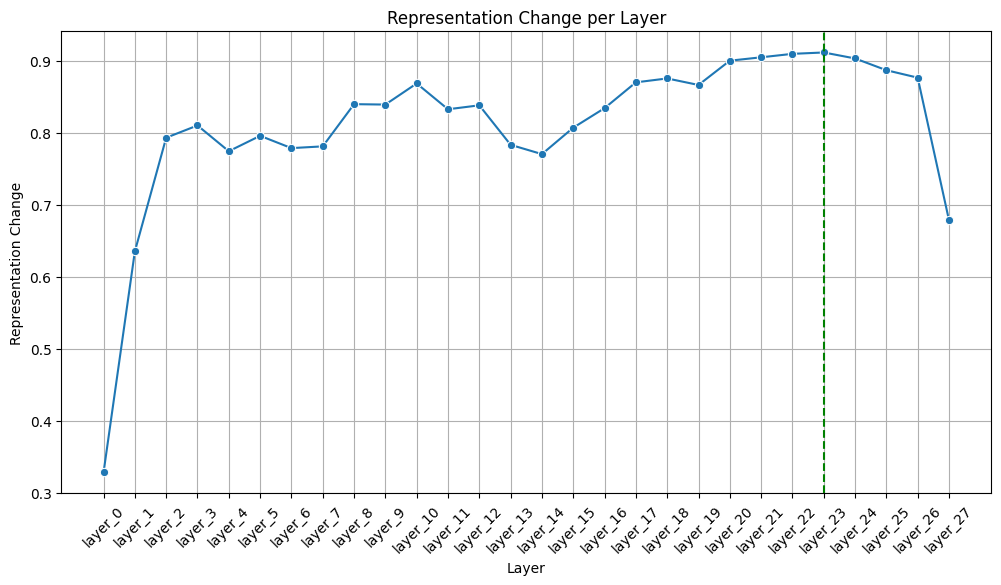

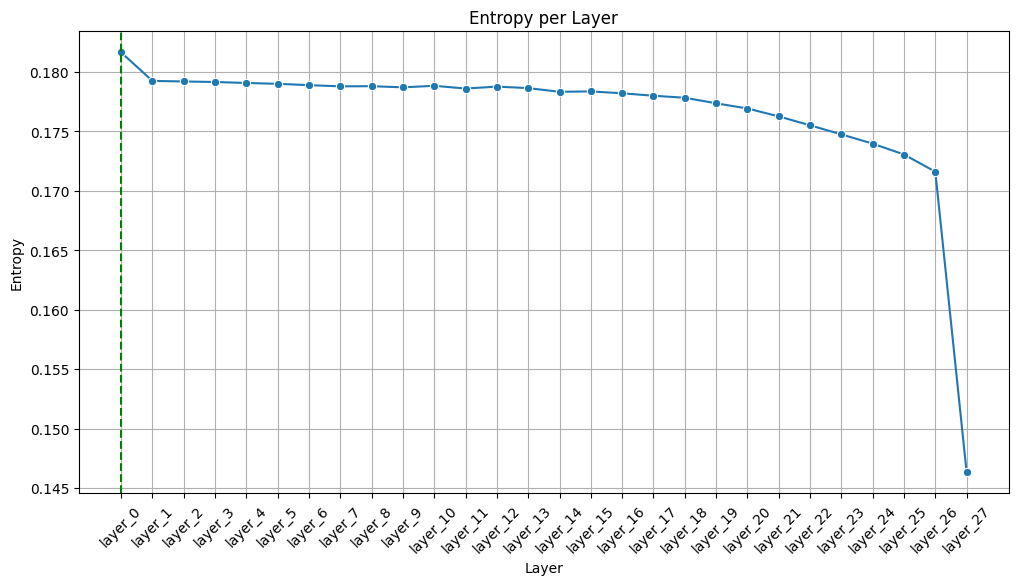

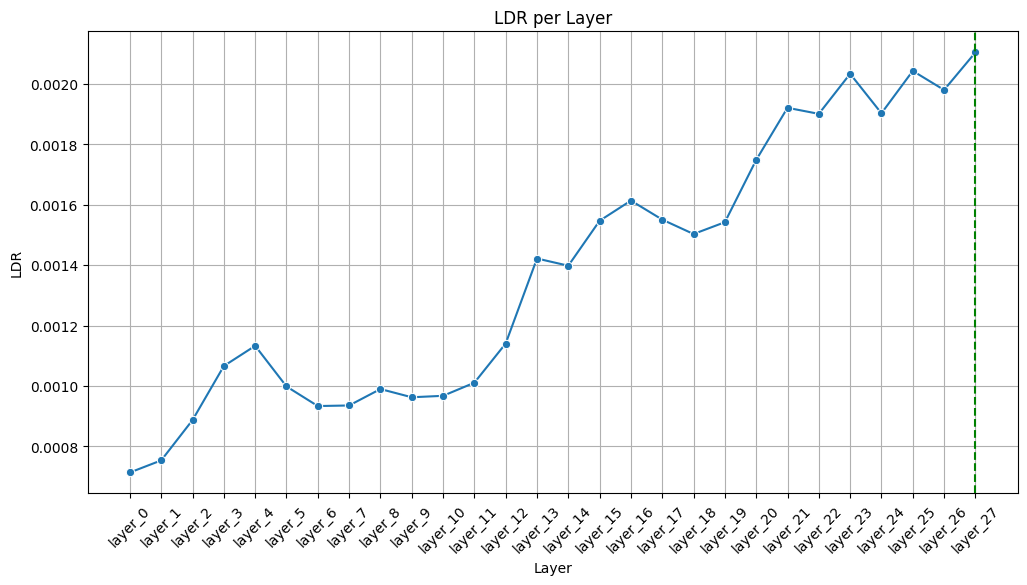

In [44]:
for metric in ["Representation Change", "Entropy", "LDR"]:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=layer_data, x="Layer", y=metric, marker="o")
    plt.axvline(x=layer_data[metric].idxmax(), color='g', linestyle='--')
    plt.title(f"{metric} per Layer")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

Хорошо заметно, что у `Representation Change` (`RC`) наблюдаются сильные изменения близко к началу, близко к концу и в середине модели. `LDR`, в то же времяЮ имеет близкие слои к `RC` (за исключением середины модели), но сдвинутые на единицу (при этом, в обоих метриках такое смещение не является несущественным). В целом, поведение этих метрик легко объяснимо: `RC` показывает, что модель меняет сильно представление, а потом немного его корректирует, повторяя процесс снова и снова. `LDR` показывает, что поведение модели меняется к её выходу.

_Замечание: заметно, что `Entropy` дала плохой результат. Всё дело в том, что я брал уже завершенные комментарии, из-за чего модель, по-сути, продолжала печатать eos, но это не сильно влияло на внутренние представления, что будет видно дальше._

## Обучение классификатора:

In [ ]:
class MLPClassifier(torch.nn.Module):
    def __init__(self, injection_model: torch.nn.Module, injection_layers: list[int], input_features: int, hidden_sizes: list[int] = [128], num_classes: int = 3):
        super(MLPClassifier, self).__init__()
        
        self.injection_model = injection_model
        self.injection_layers = injection_layers

        self.classifier = torch.nn.Sequential()
        last_size = input_features * len(injection_layers)
        for i, hidden_size in enumerate(hidden_sizes):
            self.classifier.add_module(f"fc_{i}", torch.nn.Linear(last_size, hidden_size))
            self.classifier.add_module(f"batchnorm_{i}", torch.nn.BatchNorm1d(hidden_size))
            self.classifier.add_module(f"dropout_{i}", torch.nn.Dropout(0.1))
            self.classifier.add_module(f"relu_{i}", torch.nn.ReLU())
            last_size = hidden_size

        self.classifier.add_module("output", torch.nn.Linear(last_size, num_classes))

        self.collected_features = {}
        self.hooks = self._register_hooks(self.collected_features)

    def _register_hooks(self, features: dict):
        def get_hook(layer_name):
            def hook(module, input, output):
                time_meaned = output.detach().mean(dim=1)  # mean by time
                features[layer_name] = time_meaned
            return hook

        hooks = []
        for i, layer in enumerate(self.injection_model.model.layers):
            if i in self.injection_layers:
                hooks.append(layer.register_forward_hook(get_hook(f"layer_{i}")))
        return hooks
    
    def forward(self, *args, **kwargs):
        _ = self.injection_model(*args, **kwargs)

        collected = [self.collected_features[f"layer_{i}"] for i in self.injection_layers]
        features = torch.cat(collected, dim=-1)  # mean by time

        out = self.classifier(features.to(torch.float32))
        return out
    
classifier_model = MLPClassifier(
    injection_model=model,
    injection_layers=[0, 10, 22, 27],
    input_features=3072,
    hidden_sizes=[512, 256],
    num_classes=3
).to(model.device)

In [ ]:
full_ds_len = len(data)
train_size = int(0.8 * full_ds_len)
valid_size = full_ds_len - train_size

full_ds = list(zip(data['tweet'].tolist(), data['class'].tolist()))
train_ds, valid_ds = torch.utils.data.random_split(full_ds, [train_size, valid_size])

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=16)
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=False, num_workers=16)

In [ ]:
epochs = 3
optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(epochs):
    classifier_model.train()
    train_loss = 0.0
    for text, label in tqdm(train_dl):
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
        labels = label.to(model.device)

        optimizer.zero_grad()
        outputs = classifier_model(**inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * label.size(0)
    train_loss /= len(train_dl.dataset)
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")

    classifier_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for text, label in tqdm(valid_dl):
            inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
            labels = label.to(model.device)

            outputs = classifier_model(**inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"Epoch {epoch + 1}/{epochs}, Validation Accuracy: {accuracy:.4f}")

```
Epoch 1/3, Train Loss: 0.5118
Epoch 1/3, Validation Accuracy: 0.8594
Epoch 2/3, Train Loss: 0.3328
Epoch 2/3, Validation Accuracy: 0.8336
Epoch 3/3, Train Loss: 0.3018
Epoch 3/3, Validation Accuracy: 0.8806
```

In [ ]:
classifier_model.injection_model = None  # Remove reference to the large model before saving
torch.save(classifier_model.cpu().state_dict(), "mlp_classifier.pth")

PS: строки выше были сконкатенированы в один файл и исполнены на сервере, поэтому они не имеют `output`'ов.

| Выбранные слои для mlp | train loss | validation accuracy  | комментарий                                    |
|------------------------|------------|----------------------|------------------------------------------------|
| 0                      | 0.3329     | 0.8725               | проверка на достаточность первого слоя         |
| 27                     | 0.3110     | 0.8318 (best 0.8612) | проверка на достаточность последнего слоя      |
| 7, 18, 25              | 0.2850     | 0.8848               | проверка на достаточность случайных слоев      |
| 22                     | 0.2912     | 0.8838               | проверка на достаточность общего пика LDR и RC |
| 0, 10, 22, 27          | 0.3018     | 0.8806               | набор, выбранный по графикам                   |
| 0, 3, 15, 27           | 0.2848     | 0.8850               | проверка на оптимальность выбранных точек      |
| 3, 15, 22              | 0.2797     | 0.8856               | проверка на достаточность пиков LDR            |
| 2, 9, 17, 23           | 0.2883     | 0.8876               | проверка на достаточность пиков RC **\***      |

**\*** этот чекпоинт и лежит в файле `mlp_classifier.pth`

Несмотря на малую разницу между результатами, перезапуски показывают, что явно существует зависимость между выбором слоев и качеством классификации. Также заметно, что входных и выходных данных не достаточно для хорошей классификации, что говорит о значимости подбора слоев.

Интересно, что выбор слоев, под метрику, специально взятую под задачу (LDR должен был искать слои с наилучшей разделимостью классов), не дал лучшего результата, чем более общая метрика (Representation Change). Это показывает, что аномалии стоит искать именно в тех слоя, что сильно меняют представления.